# 🕸️ OnePilot — Graph RAG Visualization
**Sprint 7B** — Visualisation du graphe FK de la source SXA

Ce notebook permet de :
- Visualiser le graphe complet des relations FK
- Explorer les voisins BFS d'une table seed
- Analyser les tables les plus connectées (hubs)
- Visualiser les chemins JOIN entre deux tables

## 1. Installation des dépendances

In [1]:
# Installation des librairies nécessaires
import subprocess, sys

packages = [
    'asyncpg',
    'networkx',
    'matplotlib',
    'plotly',
    'pandas',
    'pyvis',
    'nest_asyncio',
]

for pkg in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

print('✅ Dépendances installées')

✅ Dépendances installées


## 2. Configuration & Connexion PostgreSQL

In [2]:
import asyncio
import asyncpg
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import plotly.graph_objects as go
import nest_asyncio
from collections import deque, defaultdict
from IPython.display import display, HTML

nest_asyncio.apply()  # Permet d'utiliser asyncio dans Jupyter

# ── Configuration ─────────────────────────────────────────────────
# Modifier selon votre environnement Docker
PG_CONFIG = {
    'host':     'onepilot_postgres',      # ou l'IP de votre Docker
    'port':     5432,             # port exposé dans docker-compose
    'database': 'onepilot_dev',
    'user':     'onepilot',
    'password': 'onepilot_secret',
}

# Source ID SXA — récupéré depuis l'API /sources
import uuid
SOURCE_ID = uuid.UUID('85a0ef4b-d9af-494f-b24f-ff710c21ba43')  # ← remplace avec ton source_id

print(f'📡 Connexion à PostgreSQL : {PG_CONFIG["host"]}:{PG_CONFIG["port"]}/{PG_CONFIG["database"]}')
print(f'🔑 Source ID : {SOURCE_ID}')

📡 Connexion à PostgreSQL : onepilot_postgres:5432/onepilot_dev
🔑 Source ID : 85a0ef4b-d9af-494f-b24f-ff710c21ba43


In [3]:
# Test de connexion
async def test_connection():
    conn = await asyncpg.connect(**PG_CONFIG)
    version = await conn.fetchval('SELECT version()')
    count_rel = await conn.fetchval(
        'SELECT COUNT(*) FROM entity_relations WHERE source_id=$1',
        SOURCE_ID
    )
    count_ent = await conn.fetchval(
        'SELECT COUNT(*) FROM source_entities WHERE source_id=$1',
        SOURCE_ID
    )
    await conn.close()
    return version, count_rel, count_ent

version, count_rel, count_ent = asyncio.run(test_connection())
print(f'✅ PostgreSQL : {version[:40]}...')
print(f'📊 Entités    : {count_ent:,} tables')
print(f'🔗 Relations  : {count_rel:,} FK')

✅ PostgreSQL : PostgreSQL 16.13 (Debian 16.13-1.pgdg12+...
📊 Entités    : 1,294 tables
🔗 Relations  : 3,383 FK


## 3. Chargement du Graphe FK

In [4]:
async def load_graph_data(source_id: str):
    """Charge toutes les relations FK depuis entity_relations."""
    conn = await asyncpg.connect(**PG_CONFIG)
    rows = await conn.fetch("""
        SELECT
            source_entity,
            target_entity,
            source_field,
            target_field,
            relation_type,
            confidence,
            relation_type,
            is_confirmed
        FROM entity_relations
        WHERE source_id = $1
          AND confidence >= 0.5
        ORDER BY confidence DESC
    """, source_id)
    await conn.close()
    return [dict(r) for r in rows]

async def load_entities(source_id: str):
    """Charge les métadonnées des entités."""
    conn = await asyncpg.connect(**PG_CONFIG)
    rows = await conn.fetch("""
        SELECT name, entity_type, row_count,
               COALESCE(metadata->>'domain', '') AS domain
        FROM source_entities
        WHERE source_id = $1     """, source_id)
    await conn.close()
    return {r['name']: dict(r) for r in rows}

# Chargement
relations = asyncio.run(load_graph_data(SOURCE_ID))
entities  = asyncio.run(load_entities(SOURCE_ID))

print(f'✅ {len(relations):,} relations chargées')
print(f'✅ {len(entities):,} entités chargées')

# Aperçu
df_rel = pd.DataFrame(relations)
display(df_rel.head(10))

✅ 3,383 relations chargées
✅ 1,294 entités chargées


,source_entity,target_entity,source_field,target_field,relation_type,confidence,is_confirmed
0,RT_TRNTP_SBYD,RT_TRNTP,TRNTP_ID,TRNTP_ID,many_to_one,1.0,True
1,GS_BNKBR_ADDR_A,TH_REVDATEX,REV,REVDATEX_ID,many_to_one,1.0,True
2,GS_BNKBR_U,GS_BNKBR,BNKBR_ID,BNKBR_ID,many_to_one,1.0,True
3,GS_BNKBR_U_A,TH_REVDATEX,REV,REVDATEX_ID,many_to_one,1.0,True
4,GS_ACC_INT_U,GS_ACC_INT,ACC_ID,ACC_ID,many_to_one,1.0,True
5,GS_ACC_INT_U,TH_UDFDICT,UDFDICT_ID,UDFDICT_ID,many_to_one,1.0,True
6,GS_ACC_INT_U_A,TH_REVDATEX,REV,REVDATEX_ID,many_to_one,1.0,True
7,GS_ACC_ROOT,GS_CUR,CUR_ID,CUR_ID,many_to_one,1.0,True
8,GS_ACC_ROOT_FILES,TH_ATTFSTORE,ACC_FILES_ID,ATTFSTORE_ID,many_to_one,1.0,True
9,GS_ACC_ROOT_FILES,GS_ACC_ROOT,ACC_ID,ACC_ID,many_to_one,1.0,True


In [5]:
# Construction du graphe NetworkX
G = nx.DiGraph()  # Graphe dirigé

for rel in relations:
    src = rel['source_entity']
    tgt = rel['target_entity']
    conf = float(rel['confidence'] or 0.5)
    method = rel['relation_type'] or 'unknown'
    confirmed = bool(rel['is_confirmed'])

    G.add_edge(
        src, tgt,
        weight=conf,
        method=method,
        confirmed=confirmed,
        source_field=rel['source_field'] or '',
        target_field=rel['target_field'] or '',
        join_hint=f"{src}.{rel['source_field']} = {tgt}.{rel['target_field']}"
            if rel['source_field'] and rel['target_field'] else ''
    )

print(f'📊 Graphe NetworkX :')
print(f'   Nœuds (tables)  : {G.number_of_nodes():,}')
print(f'   Arêtes (FK)     : {G.number_of_edges():,}')
print(f'   Composantes     : {nx.number_weakly_connected_components(G)}')
print(f'   Densité         : {nx.density(G):.6f}')

📊 Graphe NetworkX :
   Nœuds (tables)  : 1,223
   Arêtes (FK)     : 2,815
   Composantes     : 4
   Densité         : 0.001884


## 4. Statistiques Globales du Graphe

In [6]:
# Top tables les plus connectées (hubs)
degree_data = []
for node in G.nodes():
    in_deg  = G.in_degree(node)
    out_deg = G.out_degree(node)
    total   = in_deg + out_deg
    degree_data.append({
        'table':       node,
        'in_degree':   in_deg,   # tables qui pointent vers elle
        'out_degree':  out_deg,  # tables vers lesquelles elle pointe
        'total_degree': total,
        'entity_type': entities.get(node, {}).get('entity_type', 'unknown'),
        'domain':      entities.get(node, {}).get('domain', ''),
    })

df_degree = pd.DataFrame(degree_data).sort_values('total_degree', ascending=False)

print('🏆 Top 20 tables les plus connectées (HUBS) :')
display(df_degree.head(20)[['table', 'in_degree', 'out_degree', 'total_degree', 'entity_type']])

🏆 Top 20 tables les plus connectées (HUBS) :


,table,in_degree,out_degree,total_degree,entity_type
3,TH_REVDATEX,451,6,457,table
12,GS_CUR,88,1,89,table
773,CS_CPW_FLTR_2_CUR,82,5,87,table
9,TH_UDFDICT,80,3,83,table
408,CS_CSH2ACC,59,3,62,table
113,GS_QUOTPL,50,6,56,table
32,GS_CMP,49,5,54,table
716,CS_AB_FLTR_2_CMP,44,4,48,table
484,CS_CSHFL,37,11,48,table
91,TH_UDFDEF,42,5,47,table


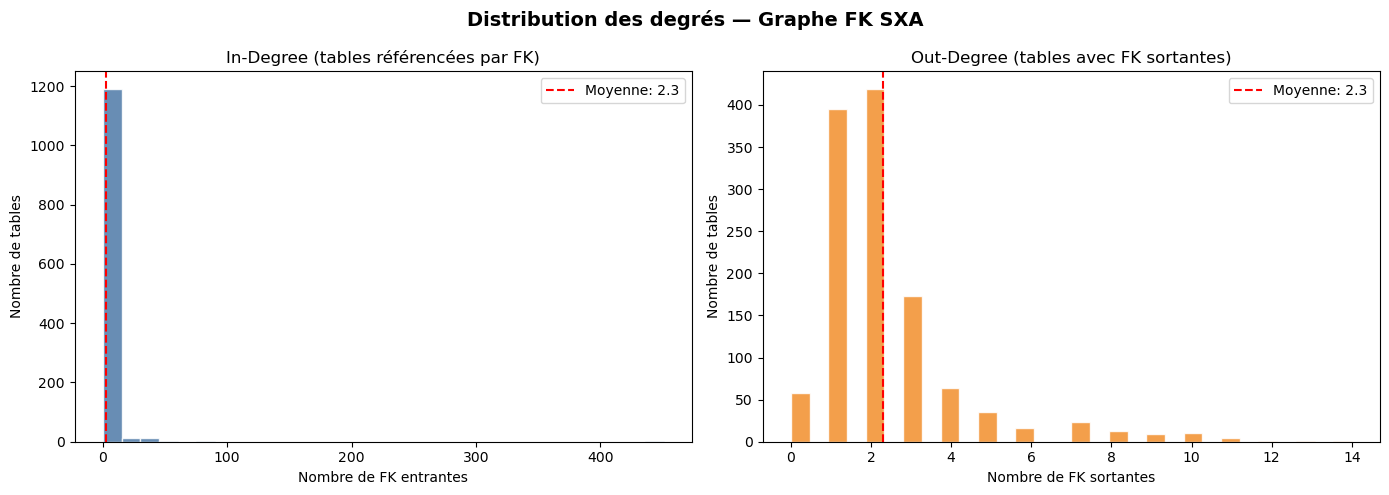

💾 Sauvegardé : graph_degree_distribution.png


In [7]:
# Distribution des degrés
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribution des degrés — Graphe FK SXA', fontsize=14, fontweight='bold')

# Histogramme in-degree
in_degrees = [d for _, d in G.in_degree()]
axes[0].hist(in_degrees, bins=30, color='#4e79a7', edgecolor='white', alpha=0.85)
axes[0].set_title('In-Degree (tables référencées par FK)')
axes[0].set_xlabel('Nombre de FK entrantes')
axes[0].set_ylabel('Nombre de tables')
axes[0].axvline(pd.Series(in_degrees).mean(), color='red', linestyle='--',
                label=f'Moyenne: {pd.Series(in_degrees).mean():.1f}')
axes[0].legend()

# Histogramme out-degree
out_degrees = [d for _, d in G.out_degree()]
axes[1].hist(out_degrees, bins=30, color='#f28e2b', edgecolor='white', alpha=0.85)
axes[1].set_title('Out-Degree (tables avec FK sortantes)')
axes[1].set_xlabel('Nombre de FK sortantes')
axes[1].set_ylabel('Nombre de tables')
axes[1].axvline(pd.Series(out_degrees).mean(), color='red', linestyle='--',
                label=f'Moyenne: {pd.Series(out_degrees).mean():.1f}')
axes[1].legend()

plt.tight_layout()
plt.savefig('graph_degree_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Sauvegardé : graph_degree_distribution.png')

## 5. Visualisation BFS — Tables Voisines

In [8]:
def bfs_subgraph(G, seed_tables, max_hops=2, max_neighbors=5):
    """Extrait le sous-graphe BFS depuis les tables seed."""
    G_undirected = G.to_undirected()
    visited = set(seed_tables)
    queue   = deque((t, 0) for t in seed_tables if t in G)
    all_nodes = list(seed_tables)
    join_paths = []

    while queue:
        current, hop = queue.popleft()
        if hop >= max_hops:
            continue

        # Voisins sortants ET entrants
        neighbors = list(G.successors(current)) + list(G.predecessors(current))
        # Tri par confiance
        neighbors_sorted = sorted(
            set(neighbors),
            key=lambda n: max(
                G[current][n]['weight'] if G.has_edge(current, n) else 0,
                G[n][current]['weight'] if G.has_edge(n, current) else 0
            ),
            reverse=True
        )[:max_neighbors]

        for neighbor in neighbors_sorted:
            # Enregistrer JOIN
            if G.has_edge(current, neighbor):
                hint = G[current][neighbor].get('join_hint', '')
                if hint:
                    join_paths.append({'from': current, 'to': neighbor,
                                       'hint': hint, 'hop': hop+1})
            elif G.has_edge(neighbor, current):
                hint = G[neighbor][current].get('join_hint', '')
                if hint:
                    join_paths.append({'from': neighbor, 'to': current,
                                       'hint': hint, 'hop': hop+1})

            if neighbor not in visited:
                visited.add(neighbor)
                all_nodes.append(neighbor)
                queue.append((neighbor, hop + 1))

    subgraph = G.subgraph(all_nodes).copy()
    return subgraph, join_paths, all_nodes


def visualize_bfs(seed_tables, max_hops=2, title=None):
    """Visualise le sous-graphe BFS avec matplotlib."""
    subG, join_paths, all_nodes = bfs_subgraph(G, seed_tables, max_hops=max_hops)

    fig, ax = plt.subplots(figsize=(16, 10))
    fig.patch.set_facecolor('#0d1117')
    ax.set_facecolor('#0d1117')

    # Layout
    if len(subG.nodes()) < 30:
        pos = nx.spring_layout(subG, k=2.5, iterations=50, seed=42)
    else:
        pos = nx.kamada_kawai_layout(subG)

    # Couleurs des nœuds
    node_colors = []
    node_sizes  = []
    for node in subG.nodes():
        if node in seed_tables:
            node_colors.append('#00d4aa')   # Seed = vert
            node_sizes.append(1200)
        else:
            node_colors.append('#4e79a7')   # Graph FK = bleu
            node_sizes.append(700)

    # Couleurs des arêtes par méthode
    edge_colors = []
    edge_widths = []
    for u, v, data in subG.edges(data=True):
        conf = data.get('weight', 0.5)
        if data.get('confirmed', False):
            edge_colors.append('#00d4aa')
            edge_widths.append(2.0)
        elif conf >= 0.9:
            edge_colors.append('#f28e2b')
            edge_widths.append(1.5)
        else:
            edge_colors.append('#6c757d')
            edge_widths.append(0.8)

    # Dessin
    nx.draw_networkx_edges(subG, pos, ax=ax,
        edge_color=edge_colors, width=edge_widths,
        arrows=True, arrowsize=15, alpha=0.7,
        connectionstyle='arc3,rad=0.1')

    nx.draw_networkx_nodes(subG, pos, ax=ax,
        node_color=node_colors, node_size=node_sizes,
        alpha=0.95)

    # Labels
    labels = {n: n[:20] + '...' if len(n) > 20 else n for n in subG.nodes()}
    nx.draw_networkx_labels(subG, pos, labels, ax=ax,
        font_size=7, font_color='white', font_weight='bold')

    # Légende
    legend_elements = [
        mpatches.Patch(color='#00d4aa', label=f'Tables seed ({len(seed_tables)})'),
        mpatches.Patch(color='#4e79a7', label=f'Tables FK découvertes ({len(all_nodes)-len(seed_tables)})'),
        mpatches.Patch(color='#00d4aa', label='FK confirmée (explicit_fk)'),
        mpatches.Patch(color='#f28e2b', label='FK haute confiance (≥0.9)'),
        mpatches.Patch(color='#6c757d', label='FK prédite (<0.9)'),
    ]
    ax.legend(handles=legend_elements, loc='upper left',
              framealpha=0.3, labelcolor='white', facecolor='#1a1f2e')

    title_str = title or f"BFS Graph RAG — Seed: {', '.join(seed_tables)} — {max_hops} hops"
    ax.set_title(title_str, color='white', fontsize=13, fontweight='bold', pad=15)
    ax.axis('off')

    plt.tight_layout()

    # Afficher JOIN paths
    if join_paths:
        print(f'\n🔗 {len(join_paths)} chemins JOIN découverts :')
        for jp in join_paths[:10]:
            print(f"   Hop {jp['hop']} → {jp['hint']}")

    return fig, subG, join_paths

print('✅ Fonctions BFS prêtes')

✅ Fonctions BFS prêtes



🔗 45 chemins JOIN découverts :
   Hop 1 → AA_LTRUL_2_AU2CMP.AU2CMP_ID = AA_AU2CMP.AU2CMP_ID
   Hop 1 → AA_LTRUL.AU2CMP_ID = AA_AU2CMP.AU2CMP_ID
   Hop 1 → AA_AU2CMP_2_AU2EMP.AU2CMP_ID = AA_AU2CMP.AU2CMP_ID
   Hop 1 → AA_AU2CMP.AU2CMP_ID = GS_CMP.CMP_ID
   Hop 1 → AA_LT.LTRUL_ID = AA_AU2CMP.AU2CMP_ID
   Hop 1 → RT_RCT2CMP.RCT2CMP_ID = GS_CMP.CMP_ID
   Hop 1 → CS_AVCDTN.CMP_ID = GS_CMP.CMP_ID
   Hop 1 → GS_CMP.CNTREG_ID = CS_CSH_R_F2CMP.CSH_R_F_ID
   Hop 1 → RC_DSCRLIMIT.CMP_ID = GS_CMP.CMP_ID
   Hop 1 → CS_CRDINTTERM.CMP_ID = GS_CMP.CMP_ID


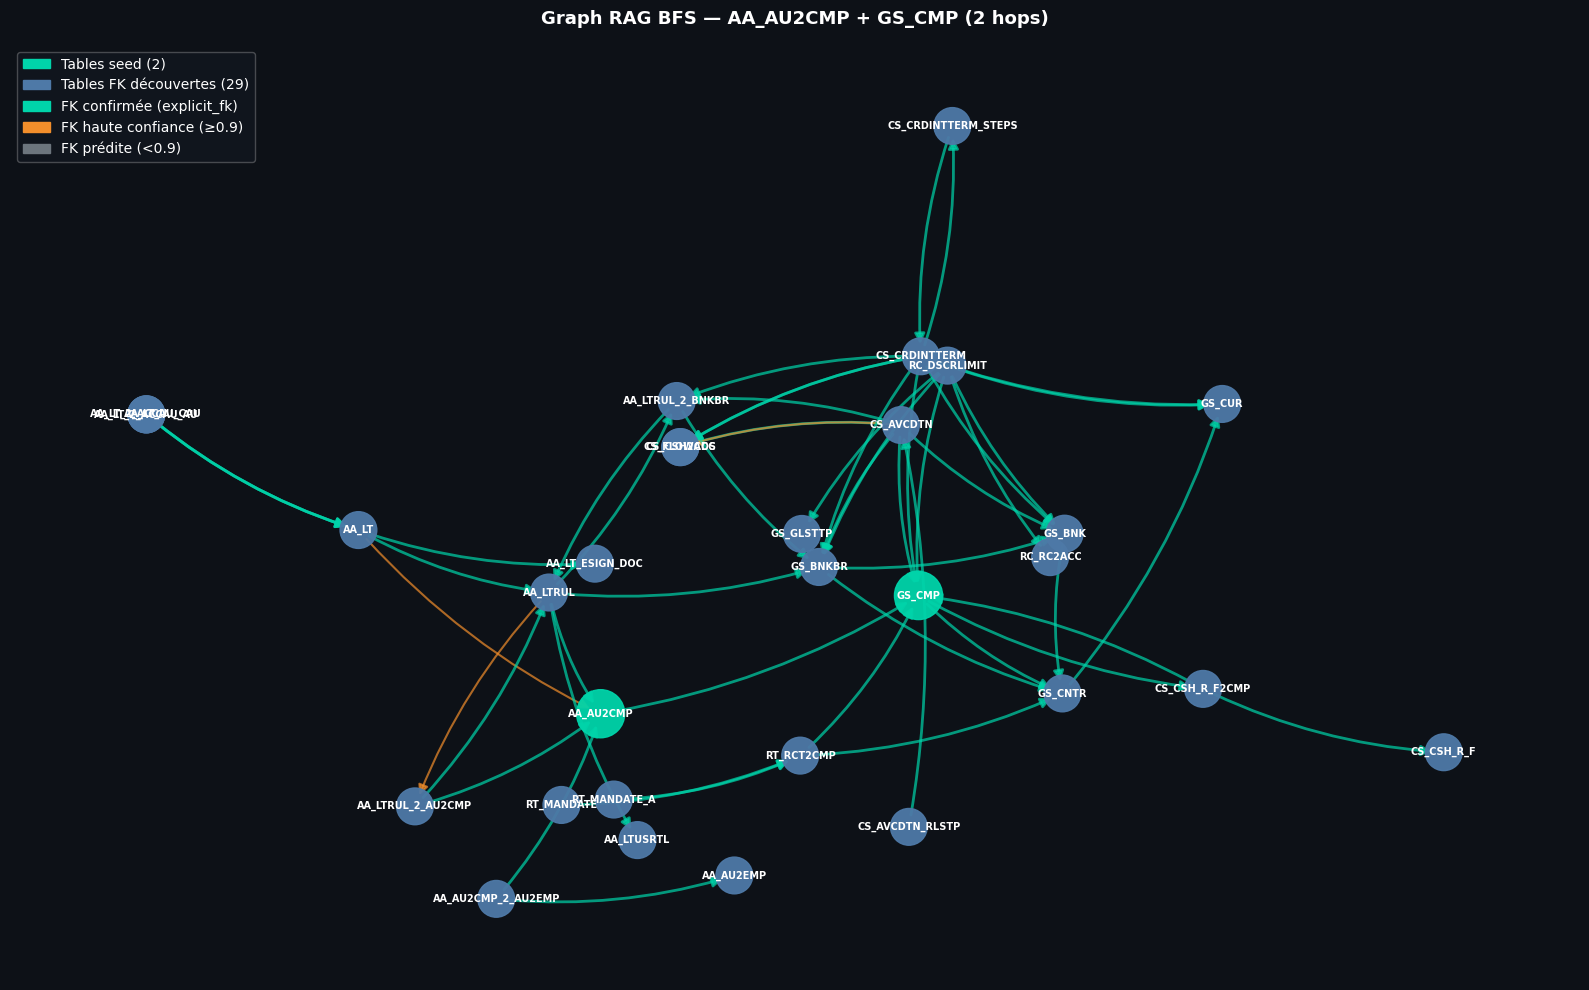

💾 Sauvegardé : bfs_AA_AU2CMP_GS_CMP.png


In [9]:
# ── Visualisation 1 : AA_AU2CMP → GS_CMP ─────────────────────────
SEED_TABLES = ['AA_AU2CMP', 'GS_CMP']

fig, subG, join_paths = visualize_bfs(
    seed_tables = SEED_TABLES,
    max_hops    = 2,
    title       = f"Graph RAG BFS — {' + '.join(SEED_TABLES)} (2 hops)"
)
plt.savefig('bfs_AA_AU2CMP_GS_CMP.png', dpi=150, bbox_inches='tight',
            facecolor='#0d1117')
plt.show()
print('💾 Sauvegardé : bfs_AA_AU2CMP_GS_CMP.png')


🔗 38 chemins JOIN découverts :
   Hop 1 → AA_BTCHTL_2_AU2EMP.AU2EMP_ID = AA_AU2EMP.AU2EMP_ID
   Hop 1 → AA_AU2EMP.AU2EMP_ID = GS_EMPL.EMPL_ID
   Hop 1 → AA_ACCAU_2_AU2EMP.AU2EMP_ID = AA_AU2EMP.AU2EMP_ID
   Hop 1 → AA_AU2EMP.AU2EMP_ID = AA_ACCAU.ACCAU_ID
   Hop 1 → AA_EMPGRP_2_AU2EMP.AU2EMP_ID = AA_AU2EMP.AU2EMP_ID
   Hop 1 → GS_PARTY_BASE_A.REV = TH_REVDATEX.REVDATEX_ID
   Hop 1 → RC_RPRCSPM_2_ACC_A.REV = TH_REVDATEX.REVDATEX_ID
   Hop 1 → TH_USRSECRINF_A.REV = TH_REVDATEX.REVDATEX_ID
   Hop 1 → AA_SIGNTP_A.REV = TH_REVDATEX.REVDATEX_ID
   Hop 1 → TH_USR_VLDT_TU_A.REV = TH_REVDATEX.REVDATEX_ID


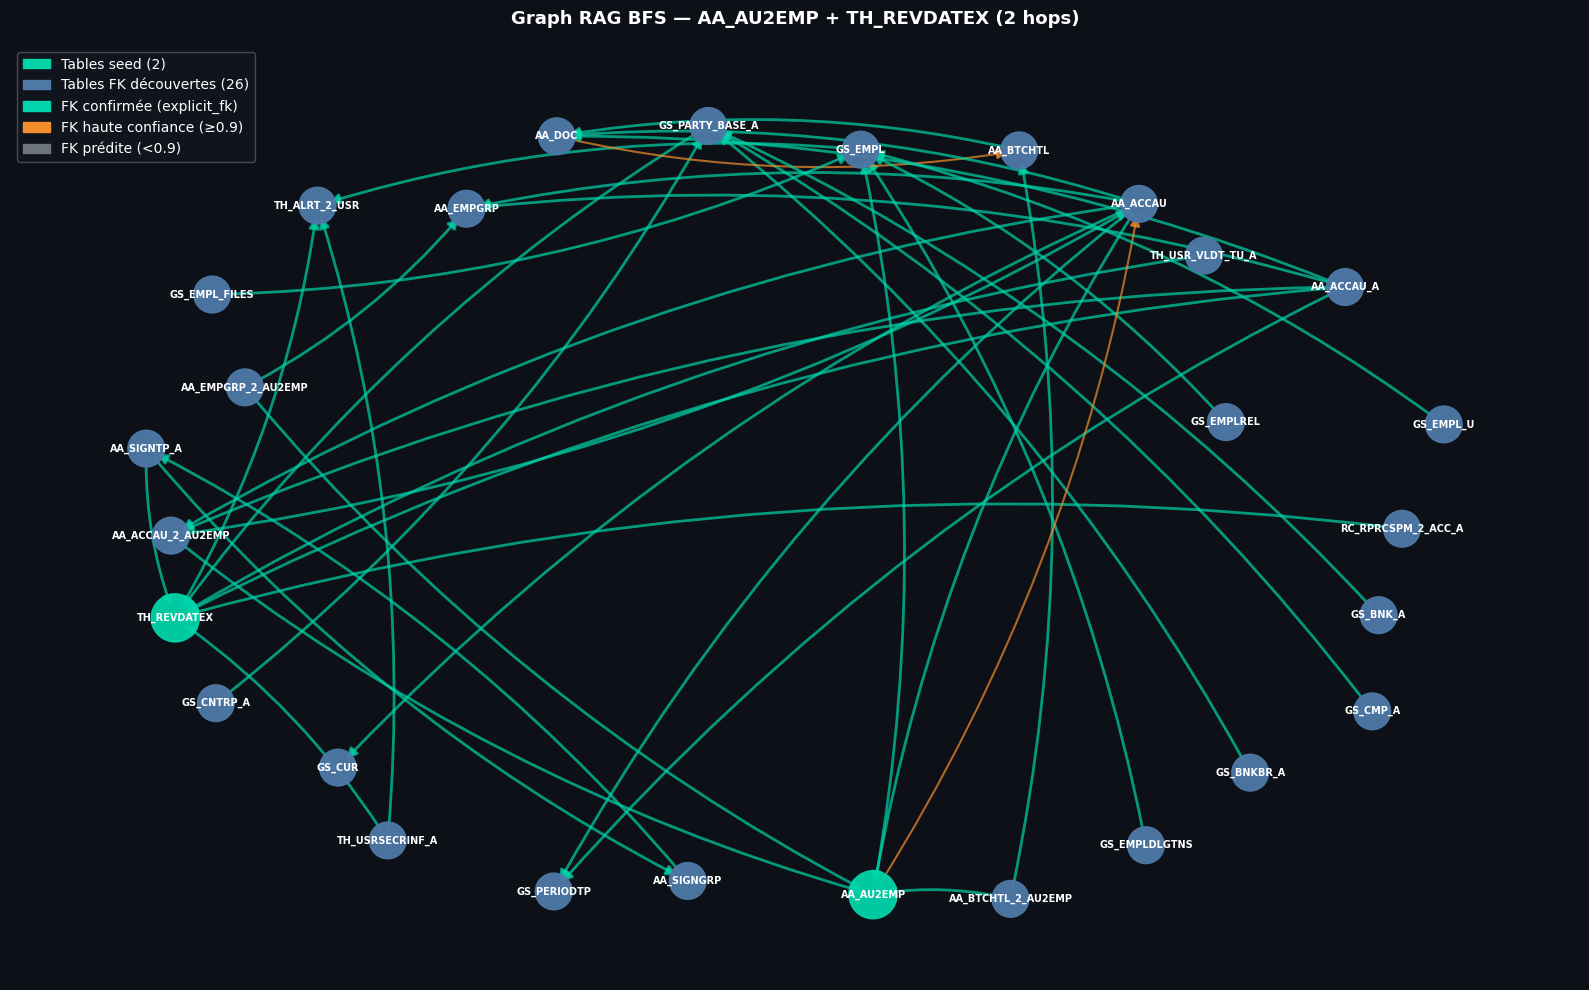

💾 Sauvegardé : bfs_AA_AU2EMP_TH_REVDATEX.png


In [10]:
# ── Visualisation 2 : AA_AU2EMP → TH_REVDATEX ────────────────────
SEED_TABLES_2 = ['AA_AU2EMP', 'TH_REVDATEX']

fig2, subG2, join_paths2 = visualize_bfs(
    seed_tables = SEED_TABLES_2,
    max_hops    = 2,
    title       = f"Graph RAG BFS — {' + '.join(SEED_TABLES_2)} (2 hops)"
)
plt.savefig('bfs_AA_AU2EMP_TH_REVDATEX.png', dpi=150, bbox_inches='tight',
            facecolor='#0d1117')
plt.show()
print('💾 Sauvegardé : bfs_AA_AU2EMP_TH_REVDATEX.png')

## 6. Visualisation Interactive (Plotly)

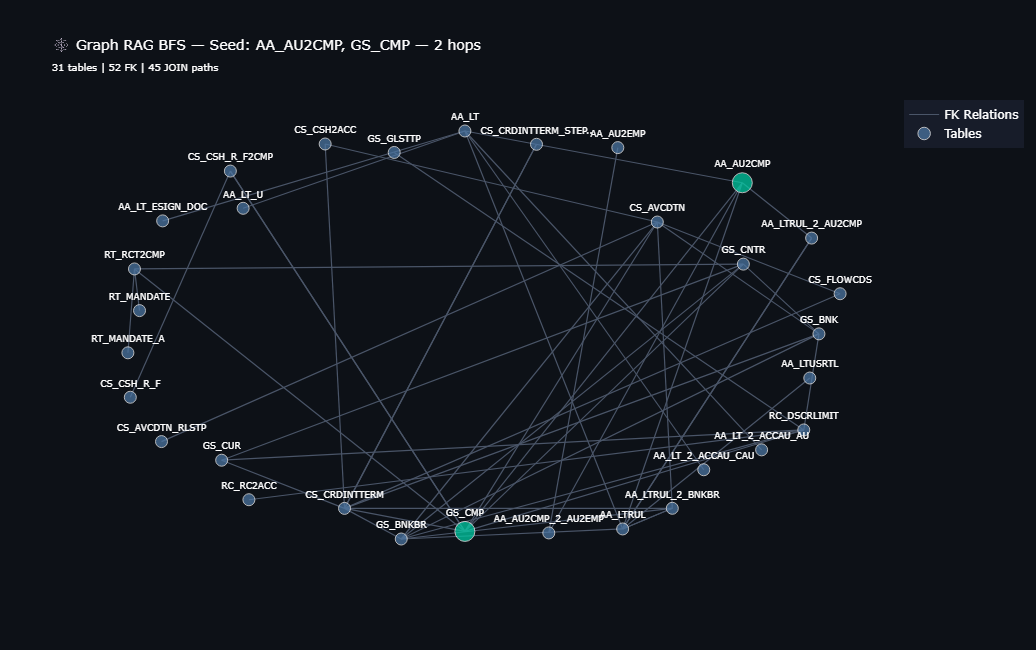


🔗 JOIN paths découverts :


,from,to,hint,hop
0,AA_LTRUL_2_AU2CMP,AA_AU2CMP,AA_LTRUL_2_AU2CMP.AU2CMP_ID = AA_AU2CMP.AU2CMP_ID,1
1,AA_LTRUL,AA_AU2CMP,AA_LTRUL.AU2CMP_ID = AA_AU2CMP.AU2CMP_ID,1
2,AA_AU2CMP_2_AU2EMP,AA_AU2CMP,AA_AU2CMP_2_AU2EMP.AU2CMP_ID = AA_AU2CMP.AU2CM...,1
3,AA_AU2CMP,GS_CMP,AA_AU2CMP.AU2CMP_ID = GS_CMP.CMP_ID,1
4,AA_LT,AA_AU2CMP,AA_LT.LTRUL_ID = AA_AU2CMP.AU2CMP_ID,1
5,RT_RCT2CMP,GS_CMP,RT_RCT2CMP.RCT2CMP_ID = GS_CMP.CMP_ID,1
6,CS_AVCDTN,GS_CMP,CS_AVCDTN.CMP_ID = GS_CMP.CMP_ID,1
7,GS_CMP,CS_CSH_R_F2CMP,GS_CMP.CNTREG_ID = CS_CSH_R_F2CMP.CSH_R_F_ID,1
8,RC_DSCRLIMIT,GS_CMP,RC_DSCRLIMIT.CMP_ID = GS_CMP.CMP_ID,1
9,CS_CRDINTTERM,GS_CMP,CS_CRDINTTERM.CMP_ID = GS_CMP.CMP_ID,1


In [11]:
def visualize_interactive(seed_tables, max_hops=2):
    """Visualisation interactive avec Plotly — survol pour voir les détails."""
    subG, join_paths, all_nodes = bfs_subgraph(G, seed_tables, max_hops=max_hops)

    # Layout
    pos = nx.spring_layout(subG, k=3.0, iterations=60, seed=42)

    # ── Arêtes ──────────────────────────────────────────────────────
    edge_x, edge_y = [], []
    edge_text = []
    for u, v, data in subG.edges(data=True):
        x0, y0 = pos[u]
        x1, y1 = pos[v]
        edge_x += [x0, x1, None]
        edge_y += [y0, y1, None]

    edge_trace = go.Scatter(
        x=edge_x, y=edge_y,
        mode='lines',
        line=dict(width=1.2, color='#4a5568'),
        hoverinfo='none',
        name='FK Relations'
    )

    # ── Nœuds ──────────────────────────────────────────────────────
    node_x, node_y, node_text, node_hover = [], [], [], []
    node_colors, node_sizes = [], []

    for node in subG.nodes():
        x, y = pos[node]
        node_x.append(x)
        node_y.append(y)
        node_text.append(node[:18] + '..' if len(node) > 18 else node)

        # Info hover
        in_d  = subG.in_degree(node)
        out_d = subG.out_degree(node)
        etype = entities.get(node, {}).get('entity_type', '?')
        rc    = entities.get(node, {}).get('row_count', '?')
        role  = '🌱 SEED' if node in seed_tables else '🔗 FK'
        node_hover.append(
            f"<b>{node}</b><br>"
            f"Rôle: {role}<br>"
            f"Type: {etype}<br>"
            f"Lignes: {rc}<br>"
            f"FK entrantes: {in_d}<br>"
            f"FK sortantes: {out_d}"
        )

        if node in seed_tables:
            node_colors.append('#00d4aa')
            node_sizes.append(20)
        else:
            node_colors.append('#4e79a7')
            node_sizes.append(12)

    node_trace = go.Scatter(
        x=node_x, y=node_y,
        mode='markers+text',
        hoverinfo='text',
        hovertext=node_hover,
        text=node_text,
        textposition='top center',
        textfont=dict(size=9, color='white'),
        marker=dict(
            size=node_sizes,
            color=node_colors,
            line=dict(width=1, color='white')
        ),
        name='Tables'
    )

    # ── Layout Plotly ────────────────────────────────────────────────
    fig = go.Figure(
        data=[edge_trace, node_trace],
        layout=go.Layout(
            title=dict(
                text=f"🕸️ Graph RAG BFS — Seed: {', '.join(seed_tables)} — {max_hops} hops<br>"
                     f"<sub>{len(all_nodes)} tables | {subG.number_of_edges()} FK | "
                     f"{len(join_paths)} JOIN paths</sub>",
                font=dict(size=14, color='white')
            ),
            paper_bgcolor='#0d1117',
            plot_bgcolor='#0d1117',
            hovermode='closest',
            showlegend=True,
            xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
            yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
            height=650,
            font=dict(color='white'),
            legend=dict(bgcolor='rgba(26,31,46,0.8)', bordercolor='#4a5568'),
        )
    )

    fig.show()

    # Tableau JOIN paths
    if join_paths:
        df_joins = pd.DataFrame(join_paths)
        print(f'\n🔗 JOIN paths découverts :')
        display(df_joins)

    return fig

# Visualisation interactive
fig_interactive = visualize_interactive(['AA_AU2CMP', 'GS_CMP'], max_hops=2)

## 7. Analyse des Hubs & Composantes

/tmp/ipykernel_46916/2163594496.py:30: UserWarning: Glyph 127942 (\N{TROPHY}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_46916/2163594496.py:31: UserWarning: Glyph 127942 (\N{TROPHY}) missing from current font.
  plt.savefig('graph_top_hubs.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
/opt/conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 127942 (\N{TROPHY}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


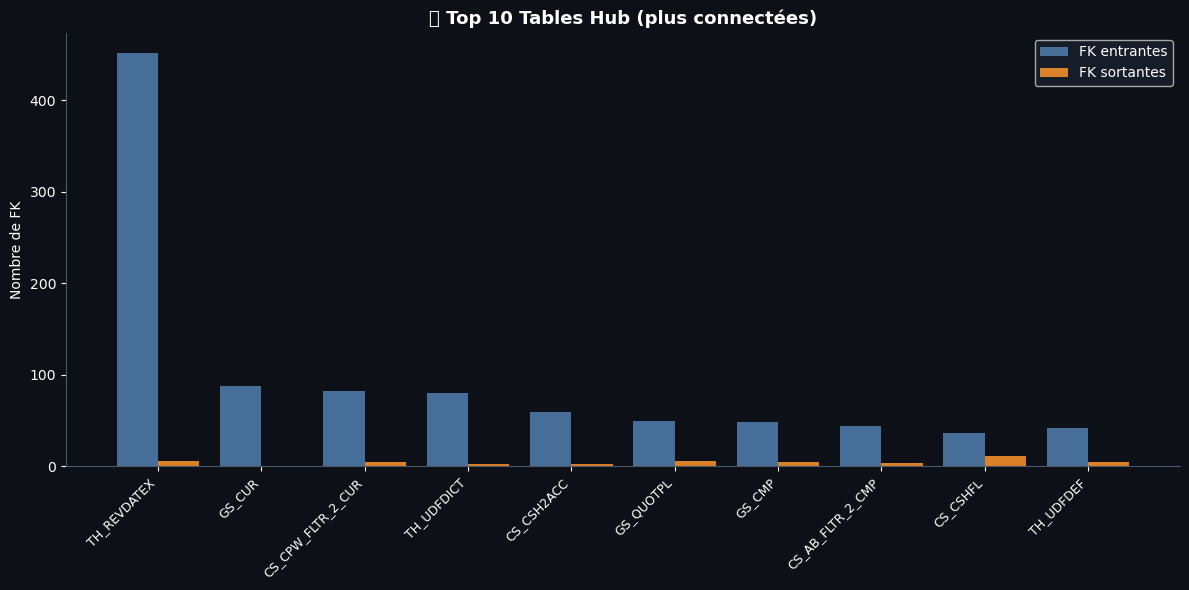

💾 Sauvegardé : graph_top_hubs.png


In [12]:
# Top 10 hubs (tables centrales)
top_hubs = df_degree.head(10)

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#0d1117')

x = range(len(top_hubs))
bars_in  = ax.bar([i - 0.2 for i in x], top_hubs['in_degree'],
                  width=0.4, label='FK entrantes', color='#4e79a7', alpha=0.9)
bars_out = ax.bar([i + 0.2 for i in x], top_hubs['out_degree'],
                  width=0.4, label='FK sortantes', color='#f28e2b', alpha=0.9)

ax.set_xticks(list(x))
ax.set_xticklabels(
    [t[:20] + '..' if len(t) > 20 else t for t in top_hubs['table']],
    rotation=45, ha='right', color='white', fontsize=9
)
ax.set_ylabel('Nombre de FK', color='white')
ax.set_title('🏆 Top 10 Tables Hub (plus connectées)', color='white',
             fontsize=13, fontweight='bold')
ax.tick_params(colors='white')
ax.spines['bottom'].set_color('#4a5568')
ax.spines['left'].set_color('#4a5568')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(labelcolor='white', facecolor='#1a1f2e')
ax.yaxis.label.set_color('white')

plt.tight_layout()
plt.savefig('graph_top_hubs.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('💾 Sauvegardé : graph_top_hubs.png')

In [13]:
# Composantes connexes
G_undirected = G.to_undirected()
components = sorted(nx.connected_components(G_undirected), key=len, reverse=True)

print(f'📊 Analyse des composantes connexes :')
print(f'   Total composantes : {len(components)}')
print(f'   Composante principale : {len(components[0])} tables')
print(f'   Tables isolées (deg=0) : {sum(1 for c in components if len(c)==1)}')
print()
print('Top 5 composantes :')
for i, comp in enumerate(components[:5], 1):
    print(f'   {i}. {len(comp)} tables — ex: {list(comp)[:3]}')

📊 Analyse des composantes connexes :
   Total composantes : 4
   Composante principale : 1213 tables
   Tables isolées (deg=0) : 0

Top 5 composantes :
   1. 1213 tables — ex: ['GS_BUDGCTS', 'GS_PARTY_BASE_A', 'CS_BNKFLENTLNK']
   2. 5 tables — ex: ['QRTZ_SIMPLE_TRIGGERS', 'QRTZ_CRON_TRIGGERS', 'QRTZ_SIMPROP_TRIGGERS']
   3. 3 tables — ex: ['TH_SRCHCFG_FIELDS', 'TH_SRCHCFG', 'TH_FTFLD']
   4. 2 tables — ex: ['TH_ID_MGR_DATA', 'TH_ID_MGR_INFO']


## 8. Visualisation Pyvis (HTML Interactif)

In [14]:
from pyvis.network import Network

def visualize_pyvis(seed_tables, max_hops=2, output_file='graph_rag.html'):
    """Génère un graphe HTML interactif avec Pyvis."""
    subG, join_paths, all_nodes = bfs_subgraph(G, seed_tables, max_hops=max_hops)

    net = Network(
        height='650px', width='100%',
        bgcolor='#0d1117', font_color='white',
        directed=True
    )
    net.barnes_hut(gravity=-8000, central_gravity=0.3, spring_length=150)

    # Ajouter les nœuds
    for node in subG.nodes():
        is_seed = node in seed_tables
        in_d  = subG.in_degree(node)
        out_d = subG.out_degree(node)
        etype = entities.get(node, {}).get('entity_type', '?')
        rc    = entities.get(node, {}).get('row_count', '?')

        net.add_node(
            node,
            label=node[:18] + '..' if len(node) > 18 else node,
            color='#00d4aa' if is_seed else '#4e79a7',
            size=25 if is_seed else 15,
            title=(
                f"<b>{node}</b><br>"
                f"Rôle: {'🌱 SEED' if is_seed else '🔗 FK'}<br>"
                f"Type: {etype}<br>"
                f"Lignes: {rc}<br>"
                f"FK in: {in_d} | FK out: {out_d}"
            ),
            borderWidth=3 if is_seed else 1,
            borderWidthSelected=4,
        )

    # Ajouter les arêtes
    for u, v, data in subG.edges(data=True):
        conf = data.get('weight', 0.5)
        confirmed = data.get('confirmed', False)
        join_hint = data.get('join_hint', f'{u} → {v}')

        net.add_edge(
            u, v,
            title=f"JOIN: {join_hint}<br>Confiance: {conf:.0%}",
            color='#00d4aa' if confirmed else ('#f28e2b' if conf >= 0.9 else '#6c757d'),
            width=2.5 if confirmed else (1.5 if conf >= 0.9 else 0.8),
            arrows='to',
        )

    net.save_graph(output_file)
    print(f'✅ Graphe interactif sauvegardé : {output_file}')
    print(f'   Ouvrir dans le navigateur pour explorer')

    # Afficher dans Jupyter
    display(HTML(f'<a href="{output_file}" target="_blank">🔗 Ouvrir {output_file}</a>'))
    return net

# Générer le graphe interactif pour AA_AU2CMP + GS_CMP
net1 = visualize_pyvis(
    seed_tables  = ['AA_AU2CMP', 'GS_CMP'],
    max_hops     = 2,
    output_file  = 'graph_AA_AU2CMP_GS_CMP.html'
)

# Générer pour AA_AU2EMP + TH_REVDATEX
net2 = visualize_pyvis(
    seed_tables  = ['AA_AU2EMP', 'TH_REVDATEX'],
    max_hops     = 2,
    output_file  = 'graph_AA_AU2EMP_TH_REVDATEX.html'
)

✅ Graphe interactif sauvegardé : graph_AA_AU2CMP_GS_CMP.html
   Ouvrir dans le navigateur pour explorer


✅ Graphe interactif sauvegardé : graph_AA_AU2EMP_TH_REVDATEX.html
   Ouvrir dans le navigateur pour explorer


## 9. Recherche de Chemin entre Deux Tables

✅ Chemin le plus court : 1 saut(s)
   AA_AU2CMP → GS_CMP

🔗 Conditions JOIN :
   Saut 1: AA_AU2CMP.AU2CMP_ID = GS_CMP.CMP_ID  (confiance: 100%)


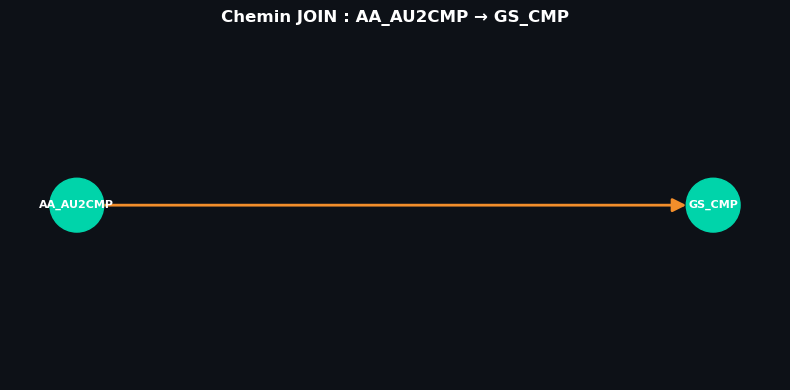


────────────────────────────────────────────────────────────

✅ Chemin le plus court : 3 saut(s)
   AA_AU2EMP → GS_EMPL → TH_USR → TH_REVDATEX

🔗 Conditions JOIN :
   Saut 1: AA_AU2EMP.AU2EMP_ID = GS_EMPL.EMPL_ID  (confiance: 100%)
   Saut 2: GS_EMPL.USR_ID = TH_USR.USR_ID  (confiance: 100%)
   Saut 3: TH_REVDATEX.USR_ID = TH_USR.USR_ID  (confiance: 100%)


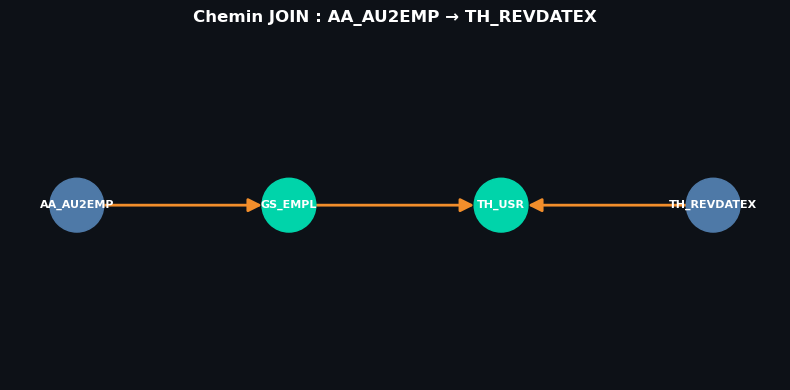

In [15]:
def find_join_path(table_a, table_b):
    """Trouve le chemin JOIN le plus court entre deux tables."""
    G_undirected = G.to_undirected()

    if table_a not in G:
        print(f'❌ Table "{table_a}" non trouvée dans le graphe')
        return
    if table_b not in G:
        print(f'❌ Table "{table_b}" non trouvée dans le graphe')
        return

    try:
        path = nx.shortest_path(G_undirected, table_a, table_b)
        print(f'✅ Chemin le plus court : {len(path)-1} saut(s)')
        print(f'   {" → ".join(path)}')
        print()
        print('🔗 Conditions JOIN :')
        for i in range(len(path)-1):
            a, b = path[i], path[i+1]
            if G.has_edge(a, b):
                hint = G[a][b].get('join_hint', f'{a} → {b}')
                conf = G[a][b].get('weight', 0)
            elif G.has_edge(b, a):
                hint = G[b][a].get('join_hint', f'{b} → {a}')
                conf = G[b][a].get('weight', 0)
            else:
                hint = f'{a} — {b}'
                conf = 0
            print(f'   Saut {i+1}: {hint}  (confiance: {conf:.0%})')

        # Visualiser ce chemin
        subG_path = G.subgraph(path).copy()
        fig, ax = plt.subplots(figsize=(max(8, len(path)*2), 4))
        fig.patch.set_facecolor('#0d1117')
        ax.set_facecolor('#0d1117')
        pos = {node: (i, 0) for i, node in enumerate(path)}

        colors = ['#00d4aa' if n in [table_a, table_b] else '#4e79a7' for n in path]
        nx.draw_networkx(subG_path, pos, ax=ax,
            node_color=colors, node_size=1500,
            font_color='white', font_size=8, font_weight='bold',
            edge_color='#f28e2b', width=2, arrows=True, arrowsize=20)
        ax.set_title(f'Chemin JOIN : {table_a} → {table_b}',
                     color='white', fontweight='bold')
        ax.axis('off')
        plt.tight_layout()
        plt.show()

    except nx.NetworkXNoPath:
        print(f'❌ Aucun chemin trouvé entre "{table_a}" et "{table_b}"')
        print('   Ces tables ne sont pas connectées via FK')

# Exemples
find_join_path('AA_AU2CMP', 'GS_CMP')
print('\n' + '─'*60 + '\n')
find_join_path('AA_AU2EMP', 'TH_REVDATEX')

## 10. Export Résumé

In [16]:
# Export CSV des statistiques
df_degree.to_csv('graph_stats_tables.csv', index=False)
df_rel.to_csv('graph_relations.csv', index=False)

# Résumé final
print('=' * 55)
print('  OnePilot — Graph RAG Résumé SXA')
print('=' * 55)
print(f'  Tables totales       : {G.number_of_nodes():,}')
print(f'  Relations FK         : {G.number_of_edges():,}')
print(f'  Composantes connexes : {len(components)}')
print(f'  Composante principale: {len(components[0])} tables')
print(f'  Hub principal        : {df_degree.iloc[0]["table"]}')
print(f'                         ({df_degree.iloc[0]["total_degree"]} connexions)')
print(f'  Méthodes FK          : {df_rel["relation_type"].value_counts().to_dict()}')
print('=' * 55)
print()
print('📁 Fichiers générés :')
print('  - graph_degree_distribution.png')
print('  - graph_top_hubs.png')
print('  - bfs_AA_AU2CMP_GS_CMP.png')
print('  - bfs_AA_AU2EMP_TH_REVDATEX.png')
print('  - graph_AA_AU2CMP_GS_CMP.html   ← interactif')
print('  - graph_AA_AU2EMP_TH_REVDATEX.html ← interactif')
print('  - graph_stats_tables.csv')
print('  - graph_relations.csv')

  OnePilot — Graph RAG Résumé SXA
  Tables totales       : 1,223
  Relations FK         : 2,815
  Composantes connexes : 4
  Composante principale: 1213 tables
  Hub principal        : TH_REVDATEX
                         (457 connexions)
  Méthodes FK          : {'many_to_one': 3383}

📁 Fichiers générés :
  - graph_degree_distribution.png
  - graph_top_hubs.png
  - bfs_AA_AU2CMP_GS_CMP.png
  - bfs_AA_AU2EMP_TH_REVDATEX.png
  - graph_AA_AU2CMP_GS_CMP.html   ← interactif
  - graph_AA_AU2EMP_TH_REVDATEX.html ← interactif
  - graph_stats_tables.csv
  - graph_relations.csv
